# Download Integration

This notebook demonstrates the **Download** stage of the Foreign Whispers dubbing pipeline.
It downloads a YouTube video and its closed captions via `yt-dlp` through the FastAPI backend.

**Prerequisites:**
- The Docker stack must be running (`docker compose --profile nvidia up -d`).
- The API should be accessible at `http://localhost:8080`.

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

IMAGES_DIR = Path("images")
IMAGES_DIR.mkdir(exist_ok=True)

# Load .env (LOGFIRE_TOKEN, HF_TOKEN, etc.)
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

# Optional: Logfire tracing (no-op shim if unavailable)
try:
    import logfire
    logfire.configure(service_name="foreign-whispers-download")
    print("Logfire tracing enabled.")
except Exception:
    class _NoopSpan:
        def __enter__(self): return self
        def __exit__(self, *a): pass
    class _noop:
        @staticmethod
        def span(name, **kw): return _NoopSpan()
        @staticmethod
        def info(*a, **kw): pass
    logfire = _noop()
    print("Logfire not configured — using no-op shim.")

Project root: /Users/skalakata/Projects/NYU/sp26_ai_class/foreign-whispers
Logfire not configured — using no-op shim.


In [2]:
from foreign_whispers.client import FWClient

fw = FWClient("http://localhost:8080")
fw.healthz()

{'status': 'ok'}

## Download Video and Captions

The API wraps `yt-dlp` to download the video MP4 and extract any available closed captions.
The `fw.download()` call returns a dict with `video_id`, `title`, and `caption_segments`.

In [4]:
VIDEO_URL = "https://www.youtube.com/watch?v=GYQ5yGV_-Oc"

with logfire.span("download", video_url=VIDEO_URL):
    dl = fw.download(VIDEO_URL)

print(f"Video ID:       {dl['video_id']}")
print(f"Title:          {dl['title']}")
print(f"Caption count:  {len(dl['caption_segments'])}")
print()
print("First 5 caption segments:")
for seg in dl["caption_segments"][:5]:
    dur = seg.get("duration", 0)
    print(f"  [{seg['start']:.2f}s, {dur:.2f}s] {seg['text']}")

Video ID:       GYQ5yGV_-Oc
Title:          Strait of Hormuz disruption threatens to shake global economy
Caption count:  170

First 5 caption segments:
  [2.32s, 3.80s] 60 Minutes overtime.
  [6.48s, 3.76s] What's the worst case scenario that
  [8.00s, 4.40s] you're worried about is that it is
  [10.24s, 5.52s] closed for weeks and weeks and weeks
  [12.40s, 5.84s] here and you start to see the global


In [9]:
# Convenience to inspect dl
import json 
print("\nFull download metadata:")
print(json.dumps(dl, indent=2))


Full download metadata:
{
  "video_id": "GYQ5yGV_-Oc",
  "title": "Strait of Hormuz disruption threatens to shake global economy",
  "caption_segments": [
    {
      "start": 2.32,
      "end": null,
      "text": "60 Minutes overtime.",
      "duration": 3.8
    },
    {
      "start": 6.48,
      "end": null,
      "text": "What's the worst case scenario that",
      "duration": 3.76
    },
    {
      "start": 8.0,
      "end": null,
      "text": "you're worried about is that it is",
      "duration": 4.4
    },
    {
      "start": 10.24,
      "end": null,
      "text": "closed for weeks and weeks and weeks",
      "duration": 5.519
    },
    {
      "start": 12.4,
      "end": null,
      "text": "here and you start to see the global",
      "duration": 5.84
    },
    {
      "start": 15.759,
      "end": null,
      "text": "economy really being impacted because",
      "duration": 4.881
    },
    {
      "start": 18.24,
      "end": null,
      "text": "the it is the life

## Inspect Downloaded Artifacts

The download stage writes files into the `pipeline_data/api/` directory tree:

- `pipeline_data/api/videos/` — source MP4 files
- `pipeline_data/api/youtube_captions/` — extracted caption JSON files

In [5]:
videos_dir = PROJECT_ROOT / "pipeline_data" / "api" / "videos"
captions_dir = PROJECT_ROOT / "pipeline_data" / "api" / "youtube_captions"

print("Videos:")
for f in sorted(videos_dir.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name}  ({size_mb:.1f} MB)")

print()
print("YouTube captions:")
for f in sorted(captions_dir.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name}  ({size_kb:.1f} KB)")

Videos:
  Strait of Hormuz disruption threatens to shake global economy.mp4  (34.3 MB)

YouTube captions:
  Strait of Hormuz disruption threatens to shake global economy.txt  (13.8 KB)


## Visualize Caption Timeline

Plot the downloaded caption segments as horizontal bars on a timeline to visualize
their temporal distribution across the video.

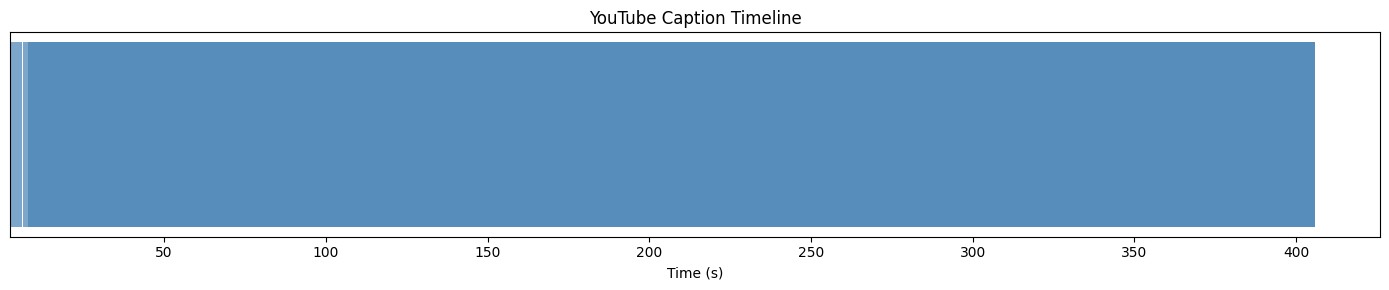

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 3))
for seg in dl["caption_segments"]:
    dur = seg.get("duration", 0)
    if dur > 0:
        ax.barh(0, dur, left=seg["start"], height=0.5, color="steelblue", alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_title("YouTube Caption Timeline")
ax.set_yticks([])
fig.tight_layout()
fig.savefig(str(IMAGES_DIR / "caption_timeline.png"), dpi=150)
plt.show()

## Summary

The download stage produced:

- **MP4 video file** in `pipeline_data/api/videos/`
- **YouTube captions JSON** in `pipeline_data/api/youtube_captions/`

These artifacts are consumed by the next pipeline stages (transcription, translation, TTS, and stitching).